In [1]:
import os

import torch
from torch import nn
from torch.utils.data import DataLoader

from spbu_bachelor_thesis.global_constants import MODELS_DIR
from spbu_bachelor_thesis.datasets import EmbeddingDataset, ClassSpecificSampler
from spbu_bachelor_thesis.train_test import (
    train_class_incremental,
    get_study_sessions,
    train_data_permutation,
)
from spbu_bachelor_thesis.nn.mlp import BaselineMLP
from spbu_bachelor_thesis.nn.kan import BaselineKAN
from spbu_bachelor_thesis.nn.architectural_kan import ArchitecturalKAN
from spbu_bachelor_thesis.nn.regularized_kan import EWCLoss
from spbu_bachelor_thesis.nn.rehearsal_kan import RehearsalKAN

# The random seed is fixed to ensure reproducibility of results
torch.manual_seed(42)
device = (
    torch.accelerator.current_accelerator()
    if torch.accelerator.is_available()
    else torch.device("cpu")
)
device

device(type='cuda')

In [2]:
# Create a directory for trained models if it doesn't exist
os.makedirs(MODELS_DIR, exist_ok=True)

#### Datasets and training parameters

In [2]:
# Offline training parameters
learning_rate = 8e-4
batch_size = 256
criterion = nn.CrossEntropyLoss()
num_epochs = 100
early_stopping = 5
# Number of class labels in the first study session in CIL
base_size = 100
# Number of class labels in the study sessions starting from the second in CIL
session_size = 10
# Number of study sessions to perform with different feature vectors permutations
# in a data permutation experiment
num_sessions = 4

# Precomputed elmbeddings of images from the CUB200 dataset generated by ResNet50 model
trainset = EmbeddingDataset("cub200_train_embed.pt")
testset = EmbeddingDataset("cub200_test_embed.pt")
# Groups of class labels to be trained on during each study session
study_sessions = get_study_sessions(testset, base_size, session_size, device)

#### Class Incremental Learning Experiment

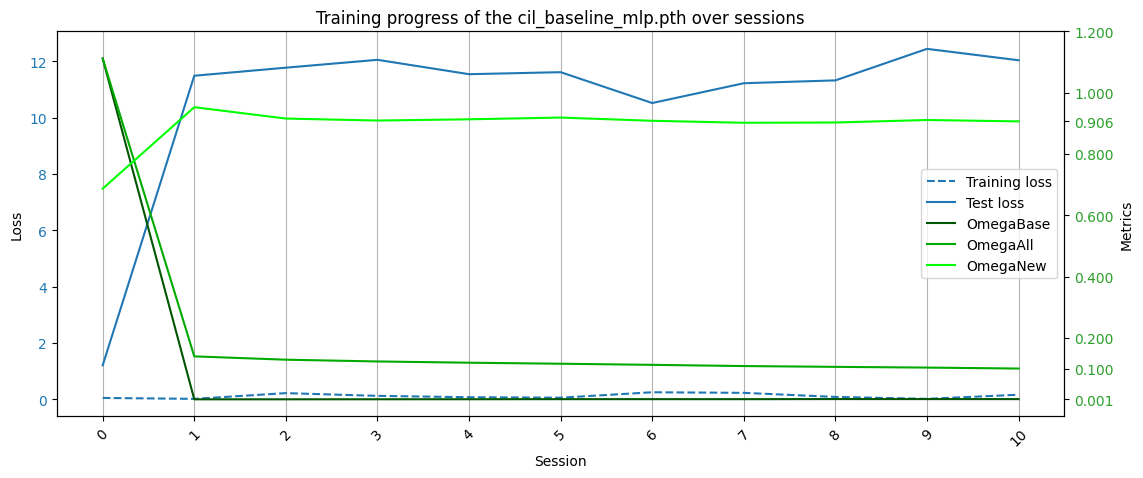

The model's weights are saved to /root/spbu-bachelor-thesis/models/cil_baseline_mlp.pth


In [4]:
baseline_mlp = BaselineMLP()
optimizer = torch.optim.NAdam(baseline_mlp.parameters(), lr=learning_rate)
train_class_incremental(
    model=baseline_mlp,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="cil_baseline_mlp.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

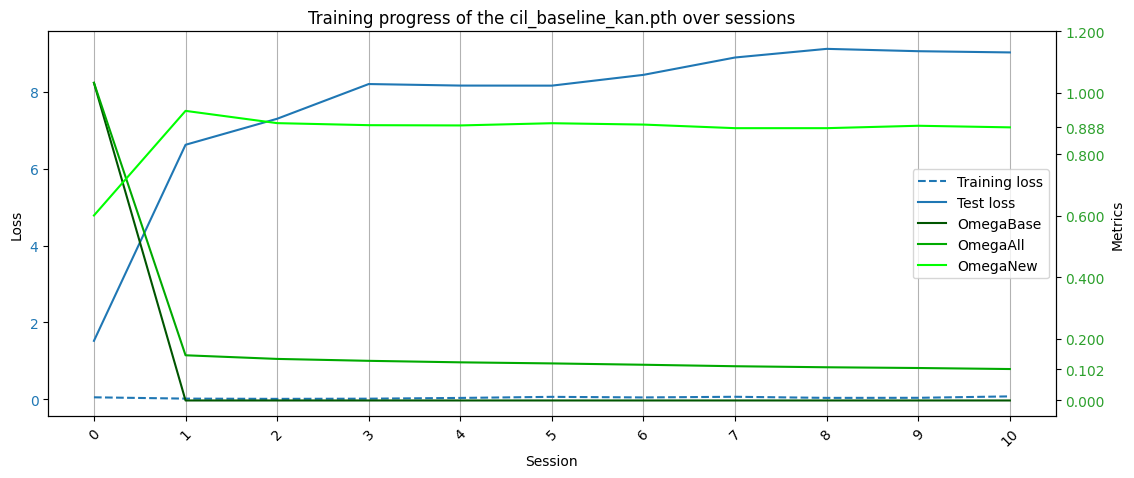

The model's weights are saved to /root/spbu-bachelor-thesis/models/cil_baseline_kan.pth


In [5]:
baseline_kan = BaselineKAN()
optimizer = torch.optim.NAdam(baseline_kan.parameters(), lr=learning_rate)
train_class_incremental(
    model=baseline_kan,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="cil_baseline_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

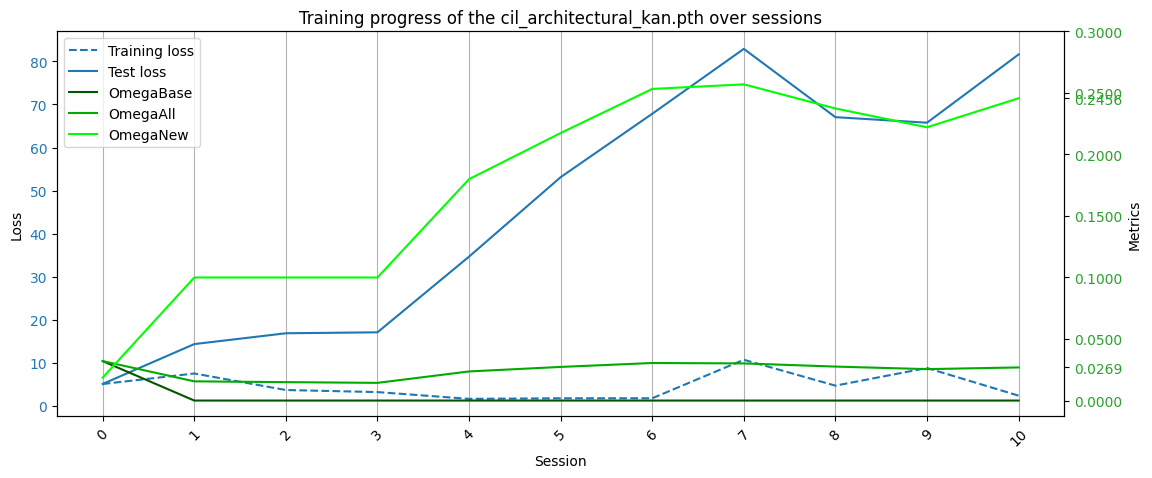

The model's weights are saved to /root/spbu-bachelor-thesis/models/cil_architectural_kan.pth


In [6]:
architectural_kan = ArchitecturalKAN()
optimizer = torch.optim.NAdam(architectural_kan.parameters(), lr=learning_rate)
train_class_incremental(
    model=architectural_kan,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="cil_architectural_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

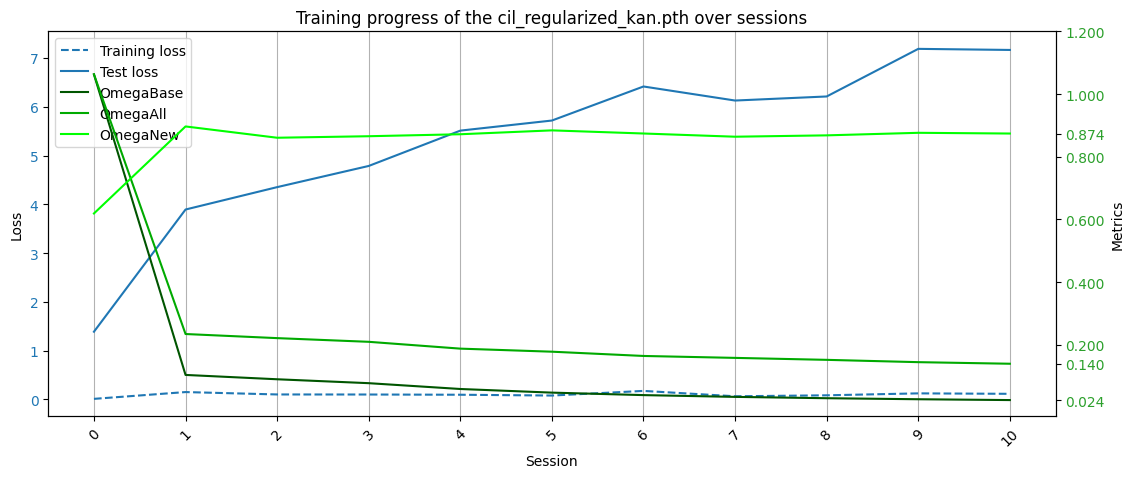

The model's weights are saved to /root/spbu-bachelor-thesis/models/cil_regularized_kan.pth


In [5]:
regularized_kan = BaselineKAN()
optimizer = torch.optim.NAdam(regularized_kan.parameters(), lr=learning_rate)
regularized_criterion = EWCLoss(
    criterion, regularized_kan, device=device, lambda_=1e5, decay=0.95
)
train_class_incremental(
    model=regularized_kan,
    trainset=trainset,
    testset=testset,
    criterion=regularized_criterion,
    optimizer=optimizer,
    save_path="cil_regularized_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

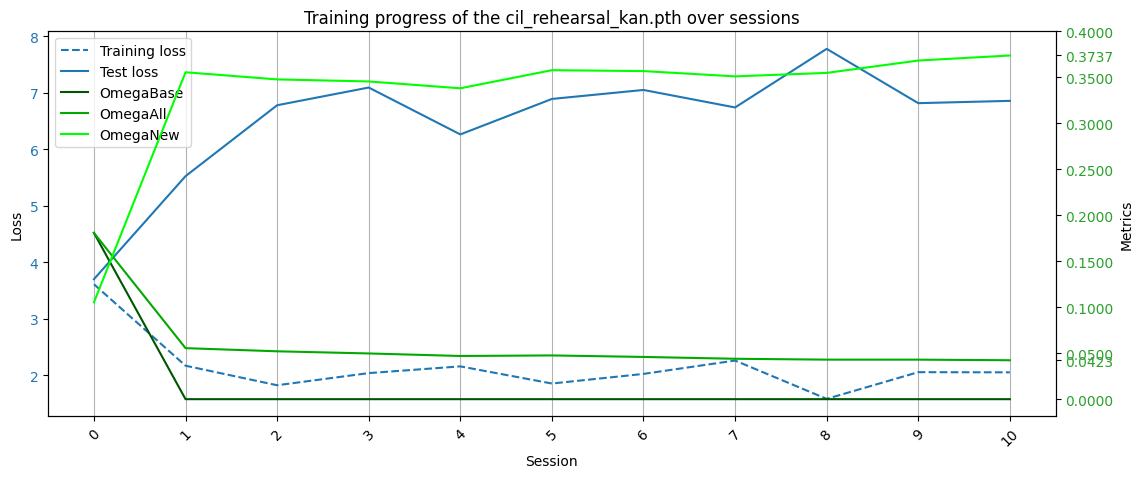

The model's weights are saved to /root/spbu-bachelor-thesis/models/cil_rehearsal_kan.pth


In [3]:
rehearsal_kan = RehearsalKAN()
optimizer = torch.optim.NAdam(rehearsal_kan.parameters(), lr=learning_rate)
curr_css = ClassSpecificSampler(trainset, study_sessions[0])
som_trainloader = DataLoader(trainset, batch_size, num_workers=2, sampler=curr_css)
rehearsal_kan.som_init(som_trainloader)
train_class_incremental(
    model=rehearsal_kan,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="cil_rehearsal_kan.pth",
    study_sessions=study_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

#### Data Permutation Experiment

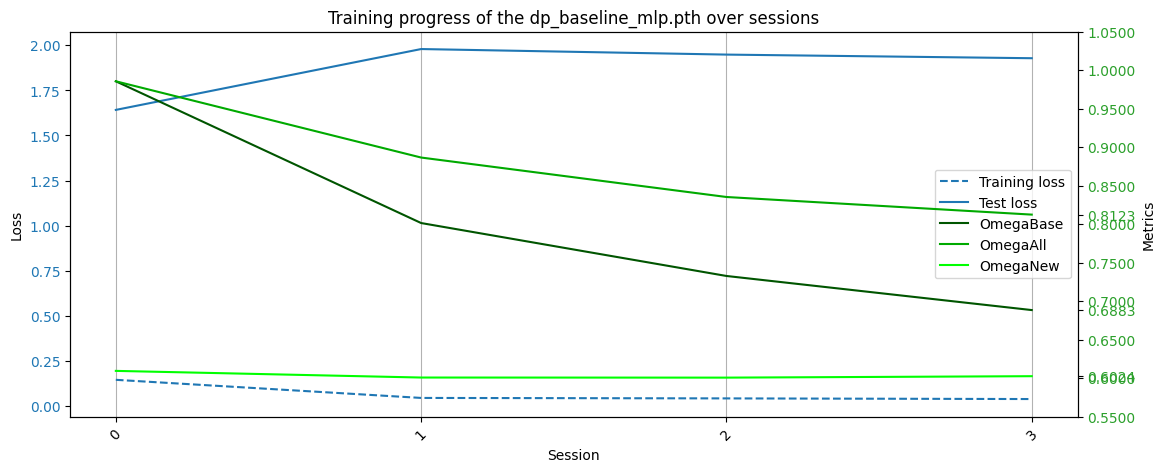

The model's weights are saved to /root/spbu-bachelor-thesis/models/dp_baseline_mlp.pth


In [6]:
baseline_mlp = BaselineMLP()
optimizer = torch.optim.NAdam(baseline_mlp.parameters(), lr=learning_rate)
train_data_permutation(
    model=baseline_mlp,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="dp_baseline_mlp.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

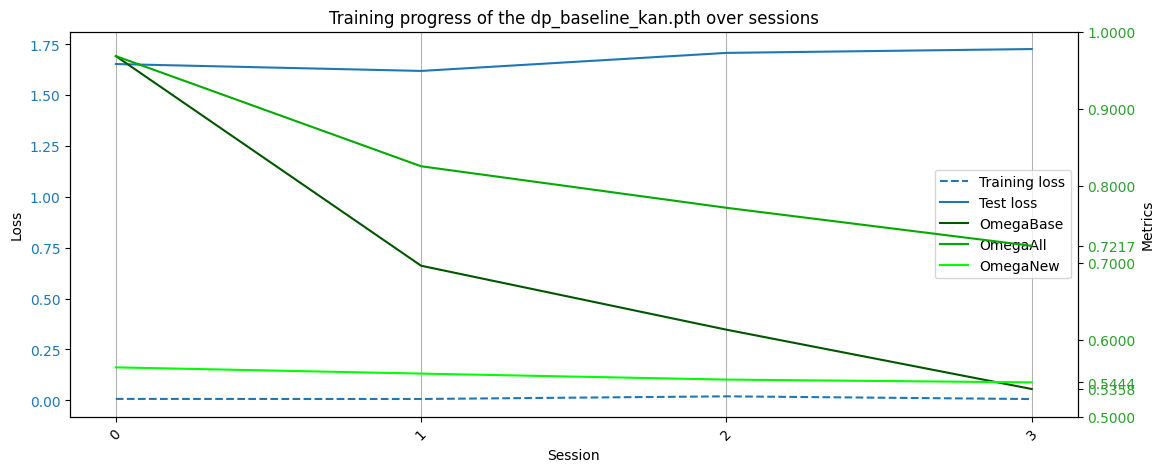

The model's weights are saved to /root/spbu-bachelor-thesis/models/dp_baseline_kan.pth


In [7]:
baseline_kan = BaselineKAN()
optimizer = torch.optim.NAdam(baseline_kan.parameters(), lr=learning_rate)
train_data_permutation(
    model=baseline_kan,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="dp_baseline_kan.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

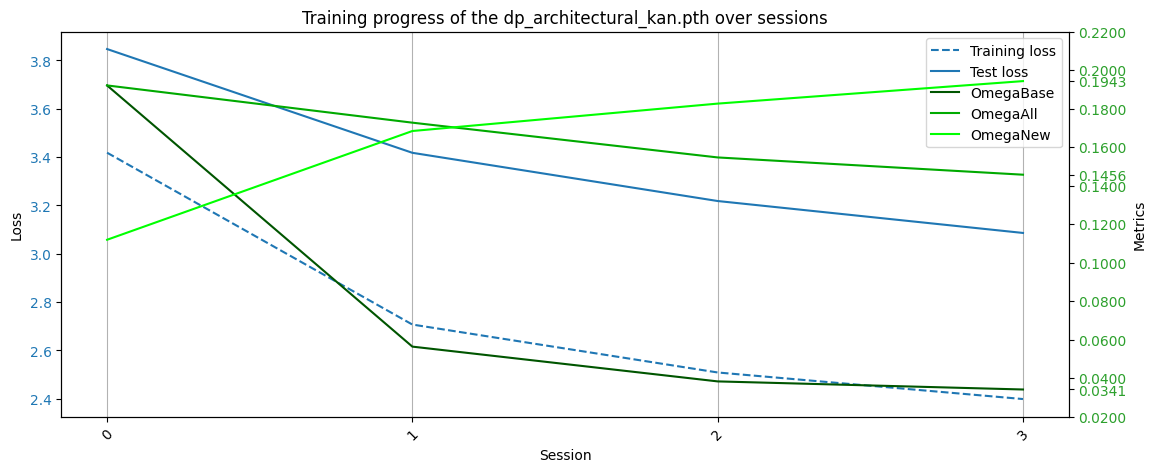

The model's weights are saved to /root/spbu-bachelor-thesis/models/dp_architectural_kan.pth


In [8]:
architectural_kan = ArchitecturalKAN()
optimizer = torch.optim.NAdam(architectural_kan.parameters(), lr=learning_rate)
train_data_permutation(
    model=architectural_kan,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="dp_architectural_kan.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

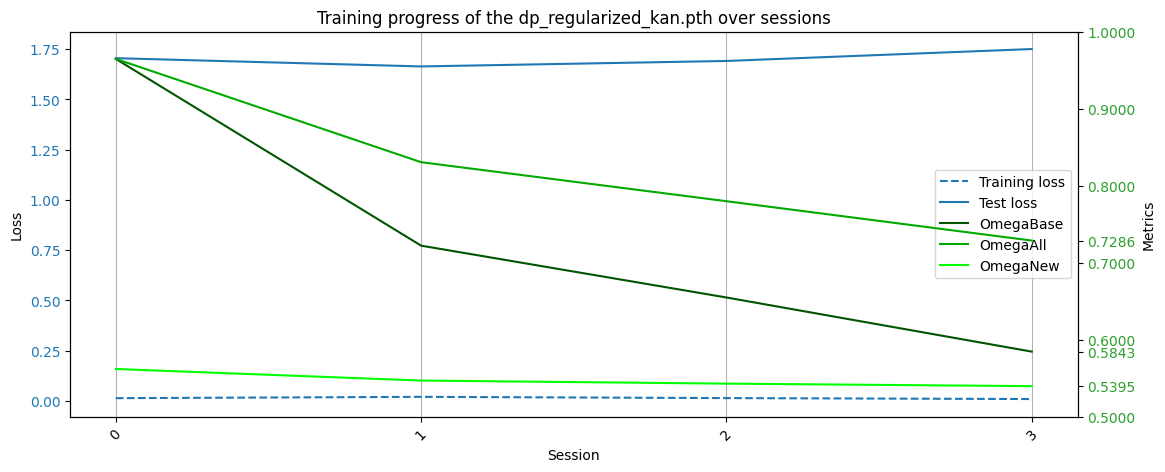

The model's weights are saved to /root/spbu-bachelor-thesis/models/dp_regularized_kan.pth


In [9]:
regularized_kan = BaselineKAN()
optimizer = torch.optim.NAdam(regularized_kan.parameters(), lr=learning_rate)
regularized_criterion = EWCLoss(
    criterion, regularized_kan, device=device, lambda_=1e5, decay=0.95
)
train_data_permutation(
    model=regularized_kan,
    trainset=trainset,
    testset=testset,
    criterion=regularized_criterion,
    optimizer=optimizer,
    save_path="dp_regularized_kan.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)

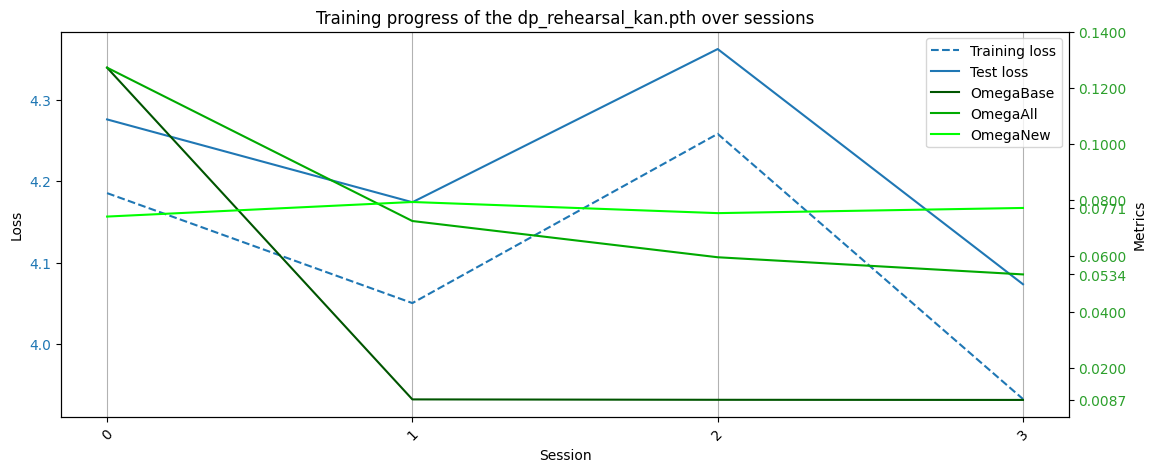

The model's weights are saved to /root/spbu-bachelor-thesis/models/dp_rehearsal_kan.pth


In [11]:
rehearsal_kan = RehearsalKAN()
optimizer = torch.optim.NAdam(rehearsal_kan.parameters(), lr=learning_rate)
som_trainloader = DataLoader(trainset, batch_size, num_workers=2, shuffle=True)
rehearsal_kan.som_init(som_trainloader)
train_data_permutation(
    model=rehearsal_kan,
    trainset=trainset,
    testset=testset,
    criterion=criterion,
    optimizer=optimizer,
    save_path="dp_rehearsal_kan.pth",
    num_sessions=num_sessions,
    batch_size=batch_size,
    num_epochs=num_epochs,
    early_stopping=early_stopping,
    device=device,
)